In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)


# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime','RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a multivariate regression model using a neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))  # Output layer with multiple neurons, one for each target variable
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=200, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Print the total number of training data points
print(f'Total Training Data Points: {X_train_scaled.shape[0]}')


Epoch 1/200
371/371 [==============================] - 3s 4ms/step - loss: 5202.6099 - val_loss: 5188.2144 - lr: 9.9611e-05
Epoch 2/200
371/371 [==============================] - 1s 3ms/step - loss: 5085.0454 - val_loss: 4996.2119 - lr: 9.9222e-05
Epoch 3/200
371/371 [==============================] - 1s 3ms/step - loss: 4785.9639 - val_loss: 4571.8989 - lr: 9.8835e-05
Epoch 4/200
371/371 [==============================] - 1s 3ms/step - loss: 4266.0239 - val_loss: 3964.3870 - lr: 9.8450e-05
Epoch 5/200
371/371 [==============================] - 1s 3ms/step - loss: 3686.2402 - val_loss: 3407.1902 - lr: 9.8066e-05
Epoch 6/200
371/371 [==============================] - 1s 3ms/step - loss: 3270.4839 - val_loss: 3080.5488 - lr: 9.7683e-05
Epoch 7/200
371/371 [==============================] - 1s 3ms/step - loss: 3075.4121 - val_loss: 2941.5625 - lr: 9.7302e-05
Epoch 8/200
371/371 [==============================] - 1s 3ms/step - loss: 3005.8794 - val_loss: 2881.2876 - lr: 9.6922e-05
Epoch 9/

371/371 [==============================] - 1s 3ms/step - loss: 2734.9482 - val_loss: 2622.5137 - lr: 5.9926e-05
Epoch 132/200
371/371 [==============================] - 1s 3ms/step - loss: 2731.1770 - val_loss: 2622.0396 - lr: 5.9693e-05
Epoch 133/200
371/371 [==============================] - 1s 3ms/step - loss: 2727.7810 - val_loss: 2621.7227 - lr: 5.9460e-05
Epoch 134/200
371/371 [==============================] - 1s 3ms/step - loss: 2722.7178 - val_loss: 2620.9331 - lr: 5.9228e-05
Epoch 135/200
371/371 [==============================] - 1s 3ms/step - loss: 2728.3301 - val_loss: 2620.8760 - lr: 5.8997e-05
Epoch 136/200
371/371 [==============================] - 1s 3ms/step - loss: 2730.2373 - val_loss: 2620.3818 - lr: 5.8767e-05
Epoch 137/200
371/371 [==============================] - 1s 3ms/step - loss: 2728.1709 - val_loss: 2620.0674 - lr: 5.8537e-05
Epoch 138/200
371/371 [==============================] - 1s 3ms/step - loss: 2731.5581 - val_loss: 2619.4905 - lr: 5.8309e-05
Epoch 

In [2]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print( X_train_scaled.shape[0])


NameError: name 'os' is not defined

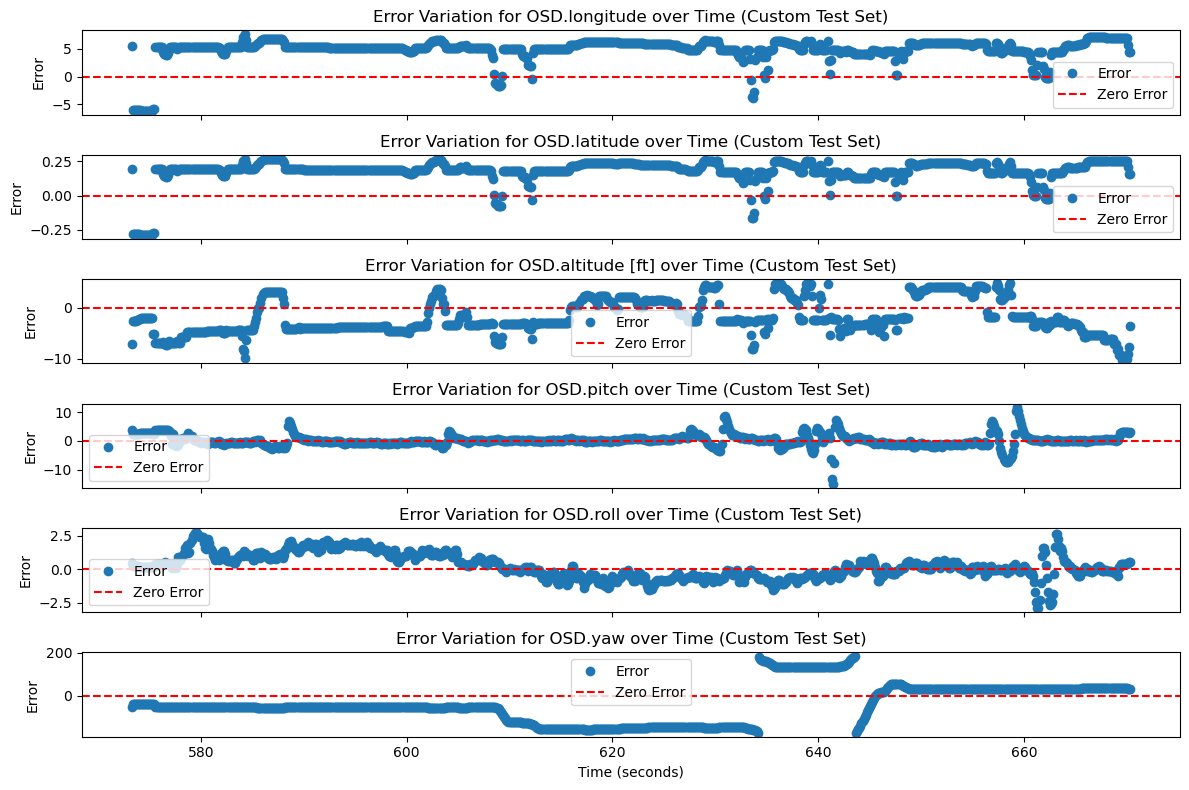

In [15]:
# Calculate the errors on the custom test set
y_test_custom = df_test_custom[output_targets]
errors_custom = y_test_custom - y_pred_custom

# Plotting error variation with time for each target variable
fig, axs = plt.subplots(len(output_targets), 1, figsize=(12, 8), sharex=True)

for i, target_variable in enumerate(output_targets):
    axs[i].plot(df_test_custom['OSD.flyTime'], errors_custom[target_variable], marker='o', linestyle='', label='Error')
    axs[i].axhline(y=0, color='r', linestyle='--', label='Zero Error')
    axs[i].set_title(f'Error Variation for {target_variable} over Time (Custom Test Set)')
    axs[i].set_ylabel('Error')
    axs[i].legend()

plt.xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


# LinearRegression

In [3]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Selecting relevant features and target variables
input_features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Build a multivariate regression model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Print the total number of training data points
print(f'Total Training Data Points: {X_train_scaled.shape[0]}')


OSD.longitude - Mean Squared Error: 0.01, R-squared: 0.27%, Mean Absolute Error: 0.06, Variance Explained: 0.27%
OSD.latitude - Mean Squared Error: 0.02, R-squared: 0.24%, Mean Absolute Error: 0.07, Variance Explained: 0.24%
OSD.height [ft] - Mean Squared Error: 391.89, R-squared: 2.47%, Mean Absolute Error: 10.94, Variance Explained: 2.47%
OSD.pitch - Mean Squared Error: 8.15, R-squared: 31.05%, Mean Absolute Error: 1.79, Variance Explained: 31.05%
OSD.roll - Mean Squared Error: 3.19, R-squared: 3.93%, Mean Absolute Error: 1.16, Variance Explained: 3.93%
OSD.yaw - Mean Squared Error: 8607.57, R-squared: 0.20%, Mean Absolute Error: 76.27, Variance Explained: 0.20%
Total Training Data Points: 29648


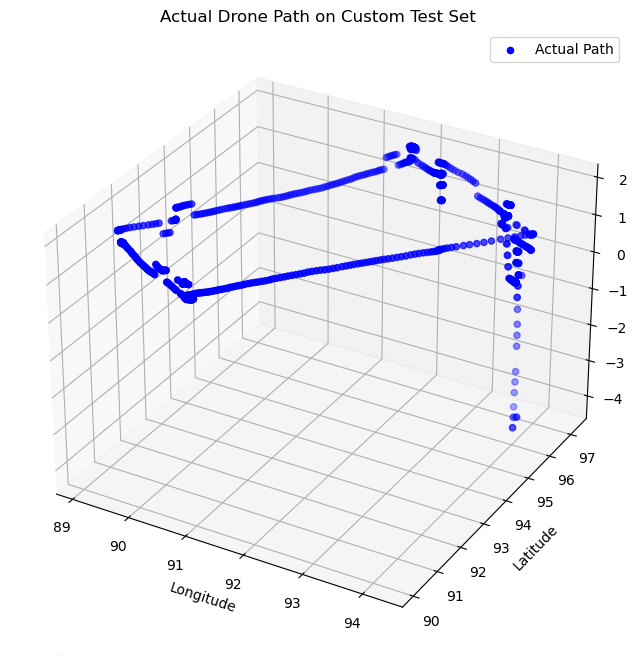

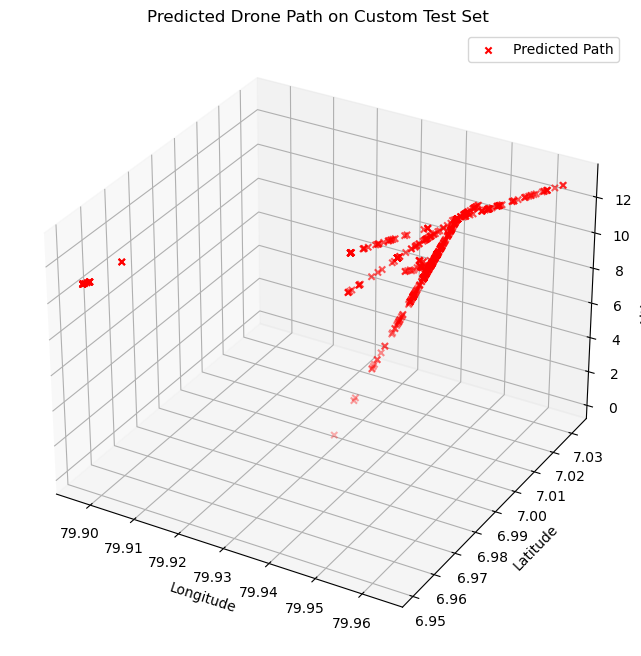

29648


In [4]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print( X_train_scaled.shape[0])


# More suggestion

Epoch 1/200
371/371 [==============================] - 2s 4ms/step - loss: 5205.6064 - val_loss: 5197.9785 - lr: 9.9611e-05
Epoch 2/200
371/371 [==============================] - 1s 3ms/step - loss: 5109.2900 - val_loss: 5039.4775 - lr: 9.9222e-05
Epoch 3/200
371/371 [==============================] - 1s 3ms/step - loss: 4872.8096 - val_loss: 4713.8228 - lr: 9.8835e-05
Epoch 4/200
371/371 [==============================] - 1s 3ms/step - loss: 4474.9971 - val_loss: 4242.0996 - lr: 9.8450e-05
Epoch 5/200
371/371 [==============================] - 1s 3ms/step - loss: 3985.8926 - val_loss: 3726.4958 - lr: 9.8066e-05
Epoch 6/200
371/371 [==============================] - 1s 3ms/step - loss: 3514.7056 - val_loss: 3284.5129 - lr: 9.7683e-05
Epoch 7/200
371/371 [==============================] - 1s 3ms/step - loss: 3172.8784 - val_loss: 2996.1436 - lr: 9.7302e-05
Epoch 8/200
371/371 [==============================] - 1s 3ms/step - loss: 2989.0530 - val_loss: 2859.6621 - lr: 9.6922e-05
Epoch 9/

371/371 [==============================] - 1s 3ms/step - loss: 2796.0623 - val_loss: 2696.6455 - lr: 5.9926e-05
Epoch 132/200
371/371 [==============================] - 1s 3ms/step - loss: 2796.1858 - val_loss: 2696.9773 - lr: 5.9693e-05
Epoch 133/200
371/371 [==============================] - 1s 3ms/step - loss: 2794.6023 - val_loss: 2696.4973 - lr: 5.9460e-05
Epoch 134/200
371/371 [==============================] - 1s 4ms/step - loss: 2789.2109 - val_loss: 2696.6992 - lr: 5.9228e-05
Epoch 135/200
371/371 [==============================] - 1s 3ms/step - loss: 2797.8557 - val_loss: 2695.9888 - lr: 5.8997e-05
Epoch 136/200
371/371 [==============================] - 1s 3ms/step - loss: 2792.4241 - val_loss: 2695.7456 - lr: 5.8767e-05
Epoch 137/200
371/371 [==============================] - 1s 3ms/step - loss: 2798.8364 - val_loss: 2696.0068 - lr: 5.8537e-05
Epoch 138/200
371/371 [==============================] - 1s 3ms/step - loss: 2794.7046 - val_loss: 2695.7075 - lr: 5.8309e-05
Epoch 

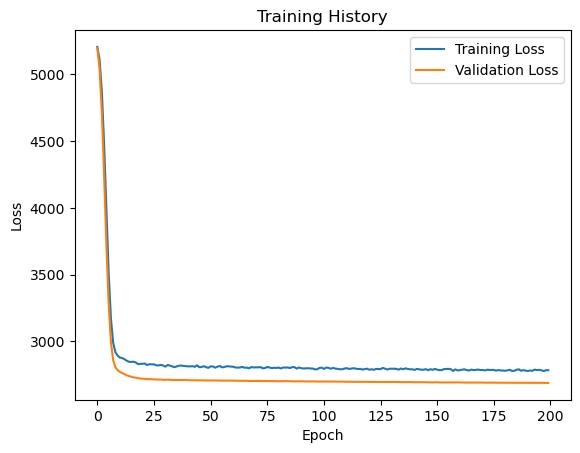

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define function to convert time string to seconds
def time_to_seconds(time_str):
    time_parts = time_str.split()
    minutes = float(time_parts[0][:-1])
    seconds = float(time_parts[1][:-1])
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Read training data
training_folder = 'training'
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Select relevant features and target variables
input_features = ['OSD.flyTime','RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Define preprocessing steps (imputation and scaling)
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocess training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Select important features using RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)
feature_selector = SelectFromModel(rf, prefit=True)

# Apply feature selection
X_train_selected = feature_selector.transform(X_train_processed)
X_test_selected = feature_selector.transform(X_test_processed)

# Build a neural network model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_selected.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(output_targets))
])

# Use a lower learning rate and add learning rate scheduling
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement early stopping and learning rate reduction on plateau
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=15, min_lr=1e-6)

# Train the model
history = model.fit(X_train_selected, y_train, epochs=200, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

# Evaluate the model on the test set
y_pred = model.predict(X_test_selected)

# Calculate and display accuracy metrics for each target variable
for i, target_variable in enumerate(output_targets):
    mse = mean_squared_error(y_test[target_variable], y_pred[:, i])
    r2 = r2_score(y_test[target_variable], y_pred[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred[:, i])
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Print the total number of training data points
print(f'Total Training Data Points: {X_train_selected.shape[0]}')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()
